In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load dataset

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Check shape

print(train_images.shape)
print(test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


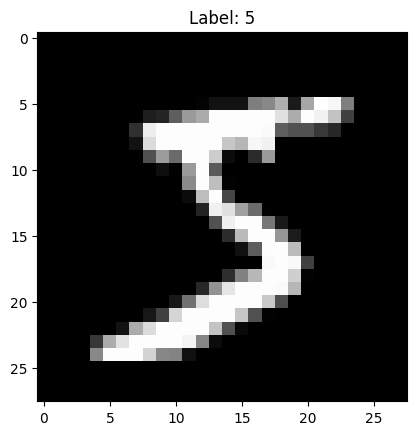

In [ ]:
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [ ]:
model = models.Sequential()

# First CNN Layer

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling Layer

model.add(layers.MaxPooling2D((2,2)))

# Second CNN Layer

model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Pooling

model.add(layers.MaxPooling2D((2,2)))

# Flatten

model.add(layers.Flatten())

# Dense Layer

model.add(layers.Dense(64, activation='relu'))

# Output Layer

model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9556 - loss: 0.1489 - val_accuracy: 0.9818 - val_loss: 0.0587
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.9847 - loss: 0.0488 - val_accuracy: 0.9872 - val_loss: 0.0372
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9850 - val_loss: 0.0451
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9925 - loss: 0.0243 - val_accuracy: 0.9907 - val_loss: 0.0299
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9941 - loss: 0.0186 - val_accuracy: 0.9882 - val_loss: 0.0381


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9882 - loss: 0.0381
Test Accuracy: 0.9882000088691711


In [ ]:
prediction = model.predict(test_images)

print("Predicted Digit:", np.argmax(prediction[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted Digit: 7


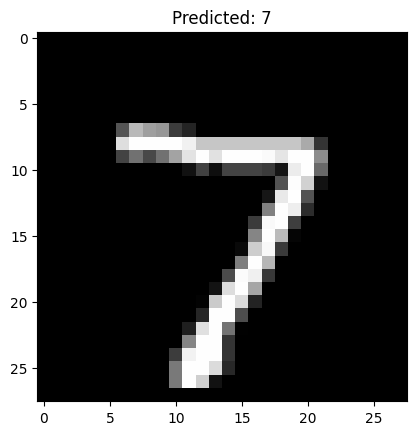

In [ ]:
plt.imshow(test_images[0].reshape(28,28), cmap='gray')

plt.title(f"Predicted: {np.argmax(prediction[0])}")

plt.show()

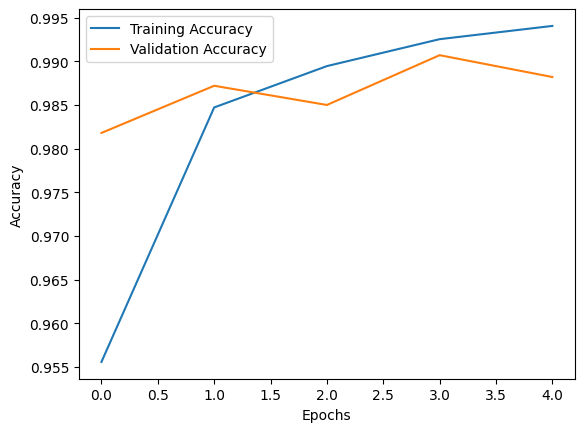

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [ ]:
model.save("handwritten_digit_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
